# Student Performance Analysis

This project analyzes student performance using statistical methods.

Dataset Description:

- Dataset contains 100 students
- Includes marks, study hours, and sleep hours
- Data is randomly generated for analysis

Import Libraries

In [2]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(42)

data = {
    "Marks": np.random.randint(40, 100, 100),
    "Study_Hours": np.random.randint(1, 10, 100),
    "Sleep_Hours": np.random.randint(4, 10, 100)
}

df = pd.DataFrame(data)

df.head()

,Marks,Study_Hours,Sleep_Hours
0,78,7,5
1,91,9,7
2,68,8,9
3,54,5,8
4,82,2,4


In [4]:
df.shape

(100, 3)

In [5]:
df.describe()

,Marks,Study_Hours,Sleep_Hours
count,100.000000,100.000000,100.00000
mean,69.580000,5.220000,6.28000
std,18.031499,2.830498,1.71199
min,41.000000,1.000000,4.00000
25%,54.000000,3.000000,5.00000
50%,68.000000,5.000000,6.00000
75%,86.000000,8.000000,7.00000
max,99.000000,9.000000,9.00000


In [5]:
df.to_csv("../data/student_data.csv", index=False)

Mean, Median, Std

In [6]:
mean_marks = df["Marks"].mean()
median_marks = df["Marks"].median()
std_marks = df["Marks"].std()

print("Mean:", mean_marks)
print("Median:", median_marks)
print("Std Dev:", std_marks)

Mean: 69.58
Median: 68.0
Std Dev: 18.03149881443441


Insight:
- Mean shows average marks of students
- Median represents middle value (robust to outliers)
- Standard deviation shows variation in marks

Compare Study vs Marks

In [7]:
df[["Marks", "Study_Hours"]].corr()

,Marks,Study_Hours
Marks,1.000000,0.035869
Study_Hours,0.035869,1.000000


Insight:
- Correlation shows relationship between study hours and marks

Detect Outliers (IQR Method)

In [9]:
# Quartiles

Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

In [10]:
# Bounds

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [12]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1: 54.0
Q3: 86.0
IQR: 32.0
Lower Bound: 6.0
Upper Bound: 134.0


In [11]:
# Find outliers

outliers = df[(df["Marks"] < lower) | (df["Marks"] > upper)]
outliers

,Marks,Study_Hours,Sleep_Hours


Insight:-
- Outliers are extreme values outside normal range

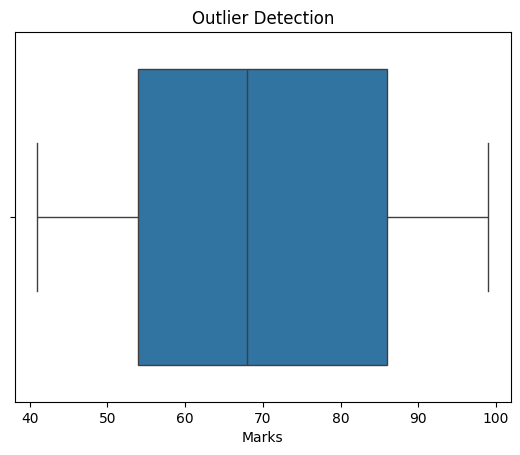

In [22]:
# Visualize Outliers

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.boxplot(x=df["Marks"])
plt.title("Outlier Detection")

plt.savefig("../images/marks_boxplot.png")
plt.show()

Insights:-

- The presence of outliers suggests that a small number of students perform significantly differently from the majority, which may require further investigation into individual factors affecting performance.

In [15]:
# Mean vs Median

df["Marks"].mean()

np.float64(69.58)

In [16]:
df["Marks"].median()

np.float64(68.0)

Insight:-
- If mean > median → right skew  
- If mean < median → left skew

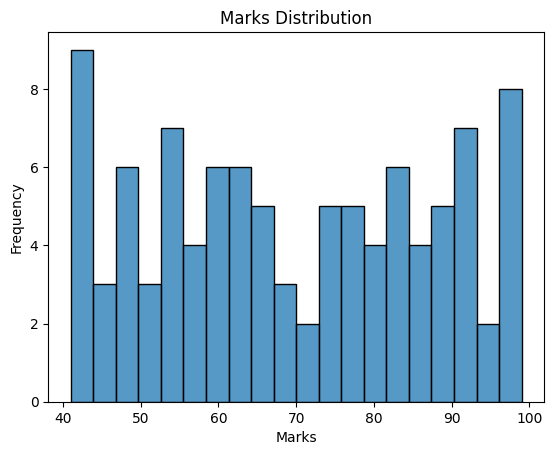

In [20]:
# Marks Distribution

plt.figure()
sns.histplot(df["Marks"], bins=20)
plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.savefig("../images/marks_distribution.png")
plt.show()

Insights:-

- Marks are concentrated around the central range, indicating that most students perform near the average level. The distribution shows moderate spread, suggesting variability but no extreme imbalance in performance.

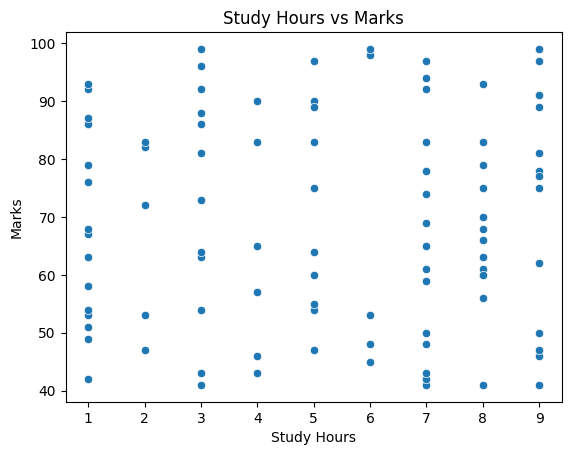

In [23]:
# Study_Hours vs Marks

plt.figure()
sns.scatterplot(x="Study_Hours", y="Marks", data=df)
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.savefig("../images/study_vs_marks.png")
plt.show()

Insights:-

- A noticeable positive trend exists between study hours and marks, indicating that increased study time generally leads to better academic performance, although the relationship is not perfectly linear.

Define Hypothesis:-

- H₀ (Null Hypothesis): Study hours have no effect on marks  
- H₁ (Alternative Hypothesis): Study hours improve marks

In [17]:
# Split Data

# We create two groups:

low_study = df[df["Study_Hours"] <= 5]["Marks"]
high_study = df[df["Study_Hours"] > 5]["Marks"]

In [19]:
# Perform t-test

from scipy import stats

t_stat, p_value = stats.ttest_ind(low_study, high_study)

print("p-value:", p_value)

p-value: 0.9510133250993665


Decision Rule:-

- If p-value < 0.05 → reject H₀  
- If p-value ≥ 0.05 → fail to reject H₀

Conclusion:-

Case 1: If p-value < 0.05

- We reject the null hypothesis.
- This means study hours have a significant effect on marks.

Case 2: If p-value ≥ 0.05

- We fail to reject the null hypothesis.
- No strong evidence that study hours affect marks.